# population across the UK

# Introduction 
This notebook aims to explore the Housing prices and population across the UK. We use a wide range of analytical techniques that includes visualisation as well as application of advanced statistical techniques.  It is aimed for teaching those techniques, rather being produced as a reference. 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import KMeans

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv


# Exploration of the data and its features

The data is substantially large - more than 7 millions observations. Numerical data brings a high level of variability. Analysis may suffer from some large dispersion within the numerical values. The datasets appears to have some categorical values as well as time series data.

In [2]:
source = '/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv'
data = pd.read_csv(source)
data.shape

(7853837, 13)

In [3]:
data.dtypes


Unnamed: 0            int64
Code                 object
Name                 object
Geography            object
Area (sq km)        float64
Price                 int64
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object
pp_sq_m             float64
est_pop             float64
dtype: object

In [4]:
data['Date of Transfer'] = pd.to_datetime(data['Date of Transfer'])
data['Year'] = data['Date of Transfer'].dt.year
data['Month'] = data['Date of Transfer'].dt.month
data['Day'] = data['Date of Transfer'].dt.day
data.dtypes
data.to_csv('data_with_year.csv')

# Numerical values and their features
It appears some large disparity in the data occurs  in the data. A large standard deviation exists. The difference between arithmetical mean and median may indicate some large prices and area skewness to the right. However, the kustosis is only large for the prices. We will need to investigate  further the presence of data in the tails for the Prices.

The people per square metres and populations appears to be skewed to the left. A low kurtosis indicates they may not many observations in the tails. 

In [5]:
data.describe()


,Unnamed: 0,Area (sq km),Price,Date of Transfer,pp_sq_m,est_pop,Year,Month,Day
count,7.853837e+06,7.853837e+06,7.853837e+06,7853837,7.853837e+06,5.208853e+06,7.853837e+06,7.853837e+06,7.853837e+06
mean,5.431394e+06,4.194698e+02,2.209744e+05,2008-06-24 11:25:39.178621440,2.599774e+03,1.372225e+06,2.007962e+03,6.711091e+00,1.691465e+01
min,1.282500e+04,1.631770e+01,1.000000e+00,2001-01-01 00:00:00,9.704739e+01,2.140000e+03,2.001000e+03,1.000000e+00,1.000000e+00
25%,2.674884e+06,7.461320e+01,1.025000e+05,2004-03-05 00:00:00,9.843264e+02,1.340490e+05,2.004000e+03,4.000000e+00,9.000000e+00
50%,5.370908e+06,1.581281e+02,1.550000e+05,2007-06-15 00:00:00,2.608139e+03,2.380160e+05,2.007000e+03,7.000000e+00,1.700000e+01
75%,8.102541e+06,4.144144e+02,2.407510e+05,2013-03-08 00:00:00,4.011644e+03,4.418580e+05,2.013000e+03,1.000000e+01,2.500000e+01
max,1.083096e+07,1.572031e+03,9.890000e+07,2017-06-29 00:00:00,5.218986e+03,7.322403e+06,2.017000e+03,1.200000e+01,3.100000e+01
std,3.154738e+06,5.338312e+02,5.708082e+05,NaN,1.613246e+03,2.584126e+06,4.943425e+00,3.349538e+00,9.011419e+00


In [6]:
cols= ['Area (sq km)', 'Price', 'pp_sq_m','est_pop']
data_num = data.loc[:, cols]
data_num.kurt()

Area (sq km)       0.622937
Price           7994.700840
pp_sq_m           -1.376422
est_pop            1.475516
dtype: float64

## Non-numerical values



Code                 object
Name                 object
Geography            object
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object

In [7]:
len(data.Code.unique())

135

In [8]:
data.Geography.unique()


array(['Unitary Authority', 'Metropolitan District',
       'Non-metropolitan District', 'Region', 'London Borough'],
      dtype=object)

In [9]:
data['Property Type'].unique()

array(['T', 'D', 'S', 'F', 'O'], dtype=object)

In [10]:
data['Old/New'].unique()

array(['N', 'Y'], dtype=object)

In [11]:
data['PPDCategory Type'].unique()

array(['A', 'B'], dtype=object)

# Is there a relationship between an estimated population and an area?


We explore the area and estimated population by Geography. Some large differences in centrality and dispersion exist. Consequently, we explore the relationship for each type of geography and across all types of geography.

In [12]:
data.groupby(['Geography']).count()['est_pop']

Geography
London Borough                152901
Metropolitan District        1490010
Non-metropolitan District    1384878
Region                        823056
Unitary Authority            1358008
Name: est_pop, dtype: int64

In [13]:
data.groupby(['Geography']).describe()['Area (sq km)']

,count,mean,min,25%,50%,75%,max,std
Geography,,,,,,,,
London Borough,227540.0,77.397572,37.2593,50.4645,80.8211,86.4887,150.1326,3.455596e+01
Metropolitan District,2191246.0,232.884266,69.4365,115.6485,142.3450,338.6198,568.0064,1.518014e+02
Non-metropolitan District,2135570.0,219.229494,21.4305,40.5530,76.6971,331.3288,1307.9377,2.619611e+02
Region,1261082.0,1572.030800,1572.0308,1572.0308,1572.0308,1572.0308,1572.0308,1.591616e-12
Unitary Authority,2038399.0,154.969484,16.3177,73.3421,79.8497,230.0933,1125.8226,1.300433e+02


In [14]:
group_by_geo = data.groupby(['Geography'])
group_by_geo.describe()['est_pop']

,count,mean,min,25%,50%,75%,max,std
Geography,,,,,,,,
London Borough,152901.0,2.548180e+05,149045.0,210044.0,277266.0,296218.0,335112.0,60986.888813
Metropolitan District,1490010.0,4.403575e+05,176826.0,266241.0,422915.0,513102.0,984642.0,237751.740921
Non-metropolitan District,1384878.0,1.083403e+05,55802.0,89836.0,107264.0,122366.0,165895.0,23795.293115
Region,823056.0,7.322403e+06,7322403.0,7322403.0,7322403.0,7322403.0,7322403.0,0.000000
Unitary Authority,1358008.0,2.031151e+05,2140.0,150334.0,191202.0,240954.0,310088.0,57311.131448


London Borough                    Axes(0.1,0.679412;0.363636x0.220588)
Metropolitan District        Axes(0.536364,0.679412;0.363636x0.220588)
Non-metropolitan District         Axes(0.1,0.414706;0.363636x0.220588)
Region                       Axes(0.536364,0.414706;0.363636x0.220588)
Unitary Authority                     Axes(0.1,0.15;0.363636x0.220588)
dtype: object

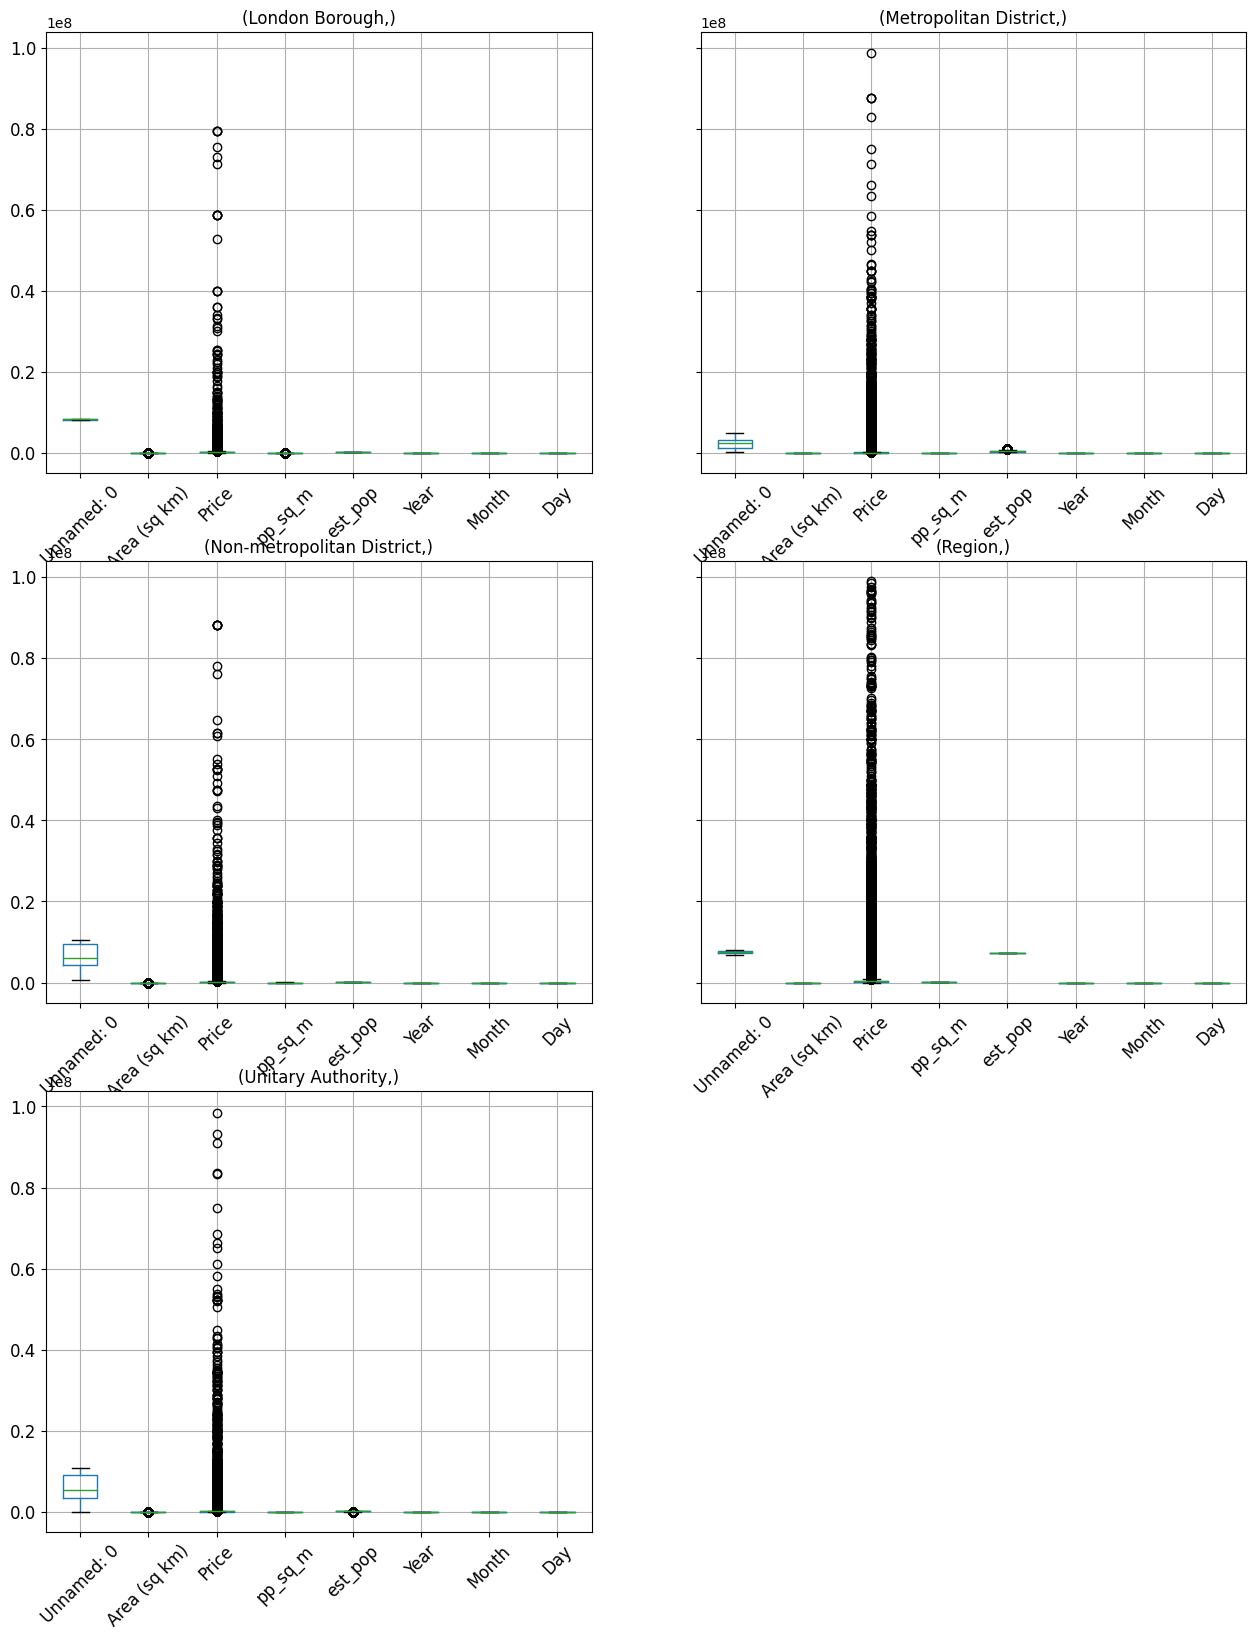

In [15]:
group_by_geo.boxplot(rot=45, fontsize=12, figsize=(15, 20))  

A stong correlation may exist between the area and extimated population. We could surmise a smaller area may have less population than a larger one. Some areas may have a higher level of concentration than other.

A visual representation may show the relationship is not linear. We use a log scale.

In [16]:
data_num.corr()

,Area (sq km),Price,pp_sq_m,est_pop
Area (sq km),1.000000,0.169982,0.409860,0.945912
Price,0.169982,1.000000,0.117433,0.335731
pp_sq_m,0.409860,0.117433,1.000000,0.618912
est_pop,0.945912,0.335731,0.618912,1.000000


Text(0, 0.5, 'Area in (sq km) (log 10)')

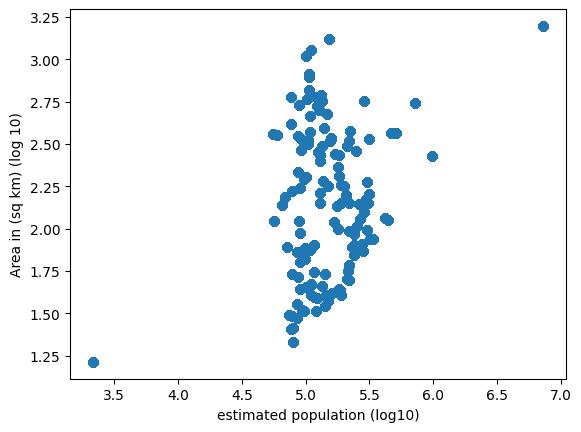

In [17]:
plt.scatter(np.log10(data_num.est_pop), np.log10(data_num['Area (sq km)']))
plt.xlabel('estimated population (log10)')
plt.ylabel('Area in (sq km) (log 10)')

## Methods

We have applied an analytical methodology based on linear regression. We used the estimated popuplation, area in squared km, and people per square km. We remove any unknown values. 

We explored linear, polynomial, and cluster relationship between the estimated population and the areas in square meter. We mostly used a linear regression, a polynomial regression, and K-means to analyse possible clusters.


In [18]:
def extract(geography : str)-> pd.DataFrame:
    rows = data.Geography.str.contains(geography)
    cols = ['Area (sq km)', 'est_pop', 'pp_sq_m']
    geo = data.loc[rows, cols]
    geo = geo.dropna()
    geo = geo.drop_duplicates()
    return geo

In [19]:
def print_summary(df : pd.DataFrame) -> None:
    print(df.shape) 
    print(df.dtypes)
    print(df.describe())


In [20]:
def analyse_linear(df : pd.DataFrame) -> None:
            x = df[['Area (sq km)']] #numpy.linalg.solve(f.A, b)
            y = df[['est_pop']]
            x = sm.add_constant(x)
            model = sm.OLS(y, x).fit()
            print(model.summary())
            print("---- params / coeficient -------")
            print(model.params)
            print('------------p values----------')
            print(model.pvalues)



In [21]:
def visualise(df : pd.DataFrame)-> None:
    plt.scatter(df['Area (sq km)'], df.est_pop)
    plt.xlabel("Area (sq kn)")
    plt.ylabel("Estimated population")
    

In [22]:
def complete_analysis(geography : str) -> None:
    df = extract(geography)
    print_summary(df)
    visualise(df)
    analyse_linear(df)

## Analysis and interpretation

### London Borough

The null hypothesis $H_0$ suggests there is no correlation between the area and the estimated population. The alternative hypothesis $H_1$ suggests the contrary.  The p-value appears to be in range $ 0.01 \leq 0.02  \leq 0.05$. It appears some moderate evidence to reject the null hypothesis in favour of the alternative hypothesis. It is, therefore inconclusive a linear relationship exists between an area and an estimated population in London Borough.


Other types of geography has no clear pattern in their data. Some strong collinearity suggests the area and estimated population are dependent variables. Therefore, no regression analysis was successfully completed.

In [23]:
rows  = data.Geography.str.contains('London Borough')
cols = ['Name', 'Area (sq km)', 'est_pop']
data.loc[rows, cols].drop_duplicates().dropna()


,Name,Area (sq km),est_pop
3930985,BARNET,86.7667,319481.0
3942717,BEXLEY,60.5784,218757.0
3946217,BROMLEY,150.1326,296218.0
3967398,CROYDON,86.4887,335112.0
3992967,ENFIELD,80.8211,277266.0
4018729,HARROW,50.4645,210044.0
4041706,HOUNSLOW,55.9628,215976.0
4052419,KINGSTON UPON THAMES,37.2593,149045.0
4064371,SUTTON,43.8477,181461.0


(9, 3)
Area (sq km)    float64
est_pop         float64
pp_sq_m         float64
dtype: object
       Area (sq km)        est_pop      pp_sq_m
count       9.00000       9.000000     9.000000
mean       72.48020  244817.777778  3636.848486
std        34.38624   64545.766174   668.873753
min        37.25930  149045.000000  1973.042497
25%        50.46450  210044.000000  3611.138624
50%        60.57840  218757.000000  3859.277949
75%        86.48870  296218.000000  4000.209344
max       150.13260  335112.000000  4162.213041
                            OLS Regression Results                            
Dep. Variable:                est_pop   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     9.050
Date:                Sun, 16 Feb 2025   Prob (F-statistic):             0.0197
Time:                        13:29:44   Log-Likelihood:                -108.18
N

/opt/conda/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


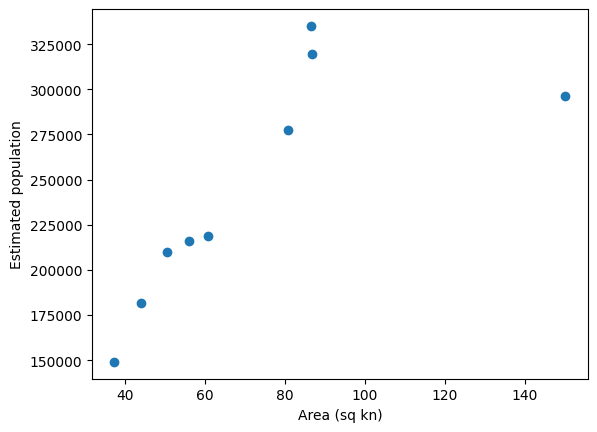

In [24]:
complete_analysis('London Borough')


Our analysis has shown the London Borough may have a polynomial relationship of degree 3 relationship between an area and the estimated population. Our results are not statiscally significant - there is not enough observations.   

(8, 3)


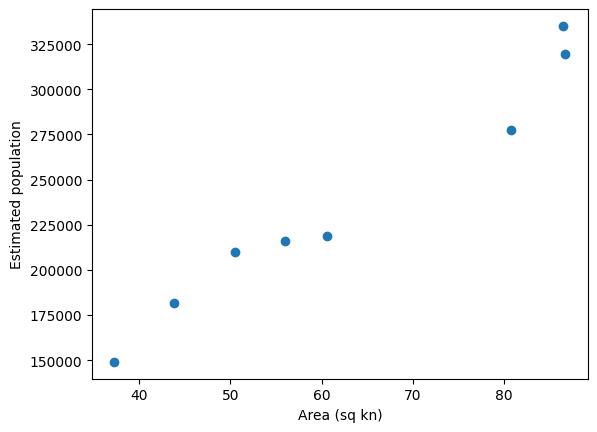

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


geo = extract('London Borough')

geo = geo.loc[geo['Area (sq km)'] < 140, :]
geo = geo.sort_values(by='Area (sq km)', ascending=True)
print(geo.shape)
visualise(geo)



In [26]:
x = geo['Area (sq km)']
y = geo['est_pop']
poly = PolynomialFeatures(degree=3, include_bias=False)

#reshape data to work properly with sklearn
poly_features = poly.fit_transform(x.values.reshape(-1, 1))
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, y.values.reshape(-1,1))


y_pred = poly_reg_model.predict(poly_features)

print("Mean Squared Error: " ,mean_squared_error(y.values.reshape(-1, 1),y_pred, multioutput = 'uniform_average'))
print("Coefficient       : ", poly_reg_model.intercept_, poly_reg_model.coef_)

Mean Squared Error:  26185868.997357935
Coefficient       :  [-766835.3079051] [[ 4.74722740e+04 -7.76448590e+02  4.31938558e+00]]


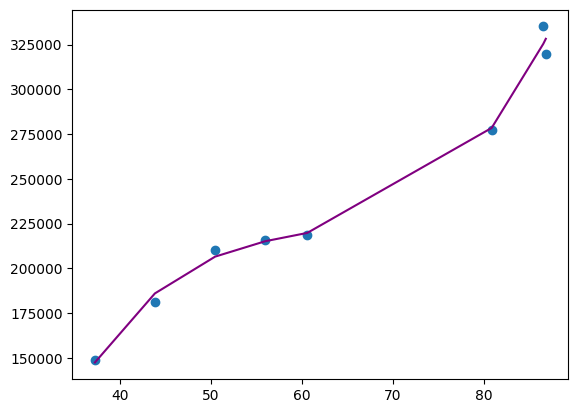

In [27]:
#use model to make predictions on response variable
y_predicted = poly_reg_model.predict(poly_features)

#create scatterplot of x vs. y
plt.scatter(x, y)

#add line to show fitted polynomial regression model
plt.plot(x, y_predicted, color='purple')

## Metropolitain district

The null hypothesis $H_0$ suggests there is no correlation between the area and the estimated population. The alternative hypothesis $H_1$ suggests the contrary.  The p-value appears to be in range $ 0.01 \leq 0.02  \leq 0.05$. It appears some moderate evidence to reject the null hypothesis in favour of the alternative hypothesis. It is, therefore inconclusive a linear relationship exists between an area and an estimated population across Metropolitain districts. The number of observations is lower than 31, and therefore more observations is required to bring some statistical significance.

In [28]:
rows  = data.Geography.str.contains('Metropolitan District')
cols = ['Name', 'Area (sq km)', 'est_pop']
data.loc[rows, cols].drop_duplicates().dropna()


,Name,Area (sq km),est_pop
110237,GATESHEAD,142.3391,191178.0
132800,NEWCASTLE UPON TYNE,113.4515,266241.0
201862,SUNDERLAND,137.4365,284601.0
340360,BOLTON,139.7923,261302.0
390312,BURY,99.4604,180655.0
410640,MANCHESTER,115.6485,422915.0
602278,OLDHAM,142.3450,218537.0
637390,ROCHDALE,158.1281,206440.0
657571,SALFORD,97.1974,216978.0
677149,STOCKPORT,126.0404,284557.0


(27, 3)
Area (sq km)    float64
est_pop         float64
pp_sq_m         float64
dtype: object
       Area (sq km)        est_pop      pp_sq_m
count     27.000000      27.000000    27.000000
mean     203.463044  326673.444444  1964.005356
std      135.911305  178115.620112   973.121974
min       69.436500  176826.000000   505.099943
25%      112.643600  218330.500000  1296.926626
50%      142.339100  284557.000000  1816.351030
75%      277.162850  315192.000000  2391.627946
max      568.006400  984642.000000  3950.956627
                            OLS Regression Results                            
Dep. Variable:                est_pop   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     6.041
Date:                Sun, 16 Feb 2025   Prob (F-statistic):             0.0213
Time:                        13:29:53   Log-Likelihood:                -361.32


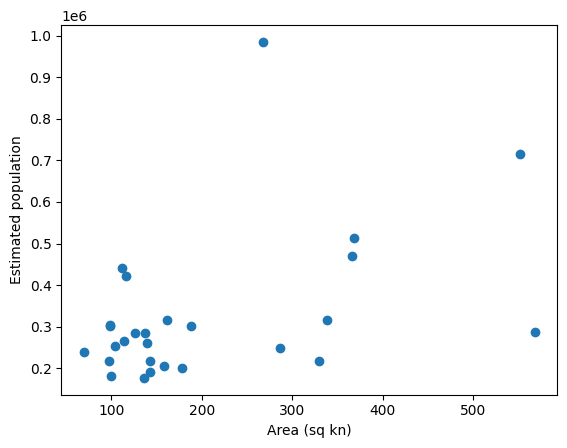

In [29]:
complete_analysis('Metropolitan District')

(24, 3)


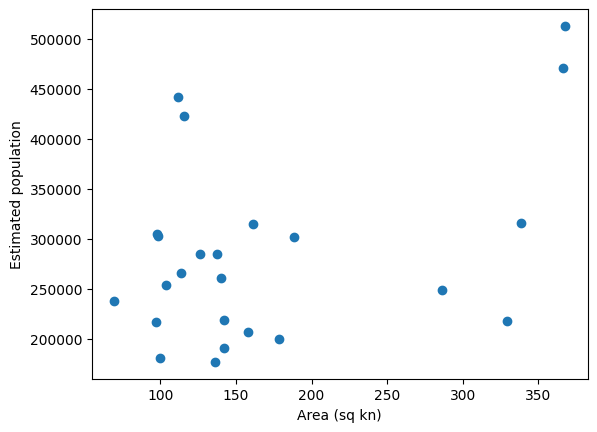

In [30]:
geo = extract('Metropolitan District')

geo = geo.loc[geo['Area (sq km)'] < 400, :]
geo = geo.loc[geo['est_pop'] < 9e5, :]

geo = geo.sort_values(by='Area (sq km)', ascending=True)
print(geo.shape)
visualise(geo)


A polynomial relationship may exists between the area and the estimated population.  However, it has been been established clearly in our analysis below. Some cluster of data may suggest some cluster may exist for the metropolitain district.

In [31]:
x = geo['Area (sq km)']
y = geo['est_pop']
poly = PolynomialFeatures(degree=5, include_bias=False)

#reshape data to work properly with sklearn
poly_features = poly.fit_transform(x.values.reshape(-1, 1))
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, y.values.reshape(-1,1))


y_pred = poly_reg_model.predict(poly_features)

print("Mean Squared Error: " ,mean_squared_error(y.values.reshape(-1, 1),y_pred, multioutput = 'uniform_average'))
print("Coefficient       : ", poly_reg_model.intercept_, poly_reg_model.coef_)



Mean Squared Error:  3820156977.9389973
Coefficient       :  [-1379587.1745336] [[ 5.11222610e+04 -5.86372387e+02  3.13474961e+00 -7.90235273e-03
   7.58399631e-06]]


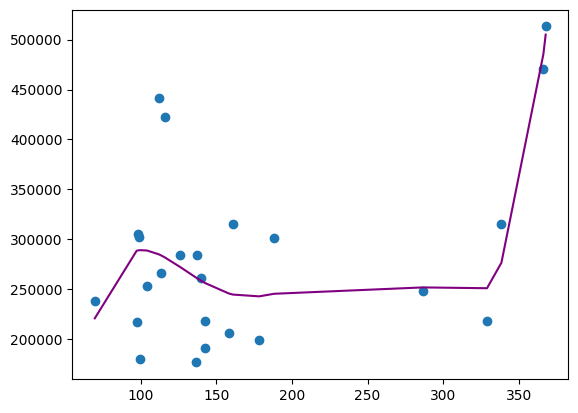

In [32]:
#use model to make predictions on response variable
y_predicted = poly_reg_model.predict(poly_features)

#create scatterplot of x vs. y
plt.scatter(x, y)

#add line to show fitted polynomial regression model
plt.plot(x, y_predicted, color='purple')

A cluster analysis - KMeans - suggest 5 centroids may be suitable. The population appears to impact on the centroid over the area.   

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

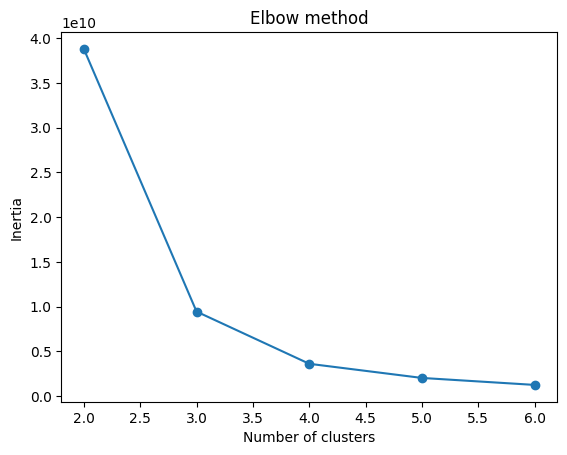

In [33]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

geo = geo.loc[data['Area (sq km)'] < 350, :]
x = geo['Area (sq km)'].values
y = geo['est_pop'].values
data_to_fit = list(zip(x, y))
inertias = []

for i in range(2,7):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_to_fit)
    inertias.append(kmeans.inertia_)

plt.plot(range(2,7), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


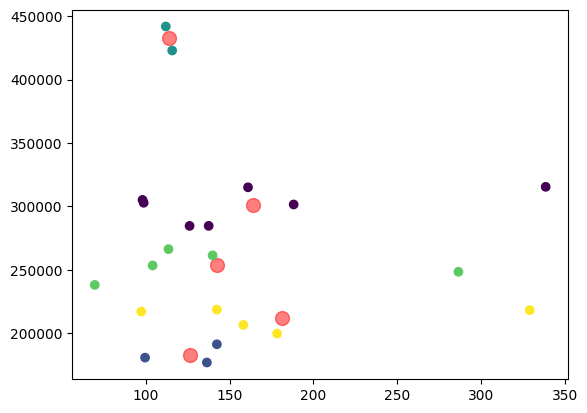

------ Centers --------


array([[1.63969600e+02, 3.01264429e+05],
       [1.26052733e+02, 1.82886333e+05],
       [1.13742100e+02, 4.32386500e+05],
       [1.42637640e+02, 2.53448200e+05],
       [1.81006040e+02, 2.11930600e+05]])

In [34]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data_to_fit)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5);
plt.scatter(x, y, c=kmeans.labels_)
plt.show()
print("------ Centers --------")
centers

### Non-metropolitan District

The null hypothesis $H_0$ suggests there is no correlation between the area and the estimated population. The alternative hypothesis $H_1$ suggests the contrary.  The p-value appears to be in range $ 0.01 \leq 0.03  \leq 0.05$. It appears some moderate evidence to reject the null hypothesis in favour of the alternative hypothesis. It is, therefore inconclusive a linear relationship exists between an area and an estimated population across Metropolitain districts. 

In [35]:
rows  = data.Geography.str.contains('Non-metropolitan District')
cols = ['Name', 'Area (sq km)', 'est_pop']
data.loc[rows, cols].drop_duplicates().dropna()


,Name,Area (sq km),est_pop
306108,BARROW-IN-FURNESS,77.8971,71960.0
319086,CARLISLE,1038.2969,100764.0
759658,BURNLEY,110.6840,89521.0
787134,CHORLEY,202.7622,100559.0
806848,LANCASTER,566.9315,134049.0
...,...,...,...
4875912,EXETER,47.0330,111180.0
4906479,CHELTENHAM,46.5961,110024.0
4942597,GLOUCESTER,40.5530,109947.0
4979207,STROUD,460.5422,108060.0


(66, 3)
Area (sq km)    float64
est_pop         float64
pp_sq_m         float64
dtype: object
       Area (sq km)        est_pop      pp_sq_m
count     66.000000      66.000000    66.000000
mean     258.307398  103076.636364  1180.008029
std      268.691958   24246.021386  1082.819562
min       21.430500   55802.000000    97.047386
25%       46.705325   86267.750000   257.300281
50%      157.164950  100661.500000   508.837899
75%      362.460375  117088.500000  2199.312867
max     1307.937700  165895.000000  3751.569025
                            OLS Regression Results                            
Dep. Variable:                est_pop   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     4.767
Date:                Sun, 16 Feb 2025   Prob (F-statistic):             0.0327
Time:                        13:30:03   Log-Likelihood:                -757.11


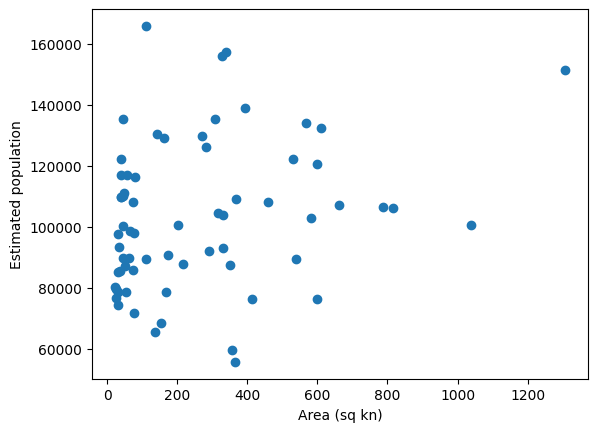

In [36]:
complete_analysis('Non-metropolitan District')

(66, 3)


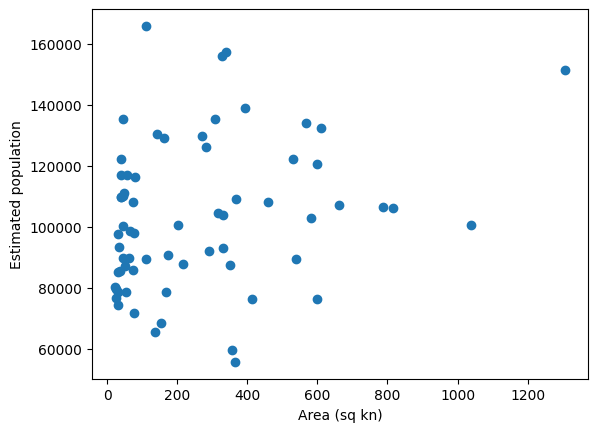

In [37]:
geo = extract('Non-metropolitan District')
geo = geo.sort_values(by='Area (sq km)', ascending=True)
print(geo.shape)
visualise(geo)


A cluster analysis - KMeans - suggest 5 centroids may be suitable. The population appears to impact on the centroid over the area.   



In [38]:

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

if False: 
    x = geo['Area (sq km)'].values
    y = geo['est_pop'].values
    data_to_fit = list(zip(x, y))
    inertias = []

    for i in range(1,11):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data_to_fit)
        inertias.append(kmeans.inertia_)

    plt.plot(range(1,11), inertias, marker='o')
    plt.title('Elbow method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


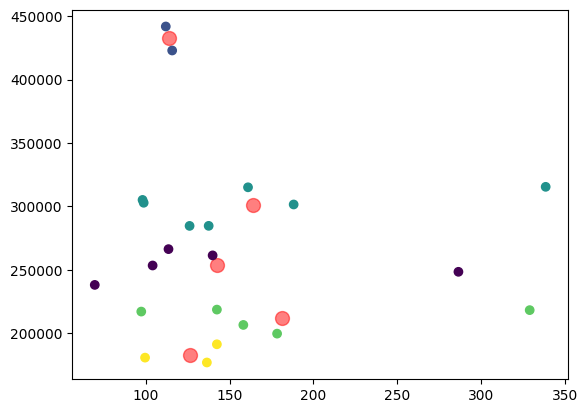

------ Centers --------


array([[1.42637640e+02, 2.53448200e+05],
       [1.13742100e+02, 4.32386500e+05],
       [1.63969600e+02, 3.01264429e+05],
       [1.81006040e+02, 2.11930600e+05],
       [1.26052733e+02, 1.82886333e+05]])

In [39]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data_to_fit)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5);
plt.scatter(x, y, c=kmeans.labels_)
plt.show()
print("------ Centers --------")
centers

### Unitary Authority

In [40]:
rows  = data.Geography.str.contains('Unitary Authority')
cols = ['Name', 'Area (sq km)', 'est_pop']
data.loc[rows, cols].drop_duplicates().dropna()


,Name,Area (sq km),est_pop
0,DARLINGTON,197.4779,97894.0
24298,HARTLEPOOL,93.7170,90152.0
45279,MIDDLESBROUGH,53.8816,141233.0
79564,STOCKTON-ON-TEES,204.9331,183795.0
232679,BLACKPOOL,34.8709,142270.0
265981,WARRINGTON,180.6279,191202.0
1043317,YORK,271.9314,181291.0
1600231,DERBY,78.0311,230726.0
1661744,LEICESTER,73.3421,282757.0
1755801,NOTTINGHAM,74.6132,268939.0


(32, 3)
Area (sq km)    float64
est_pop         float64
pp_sq_m         float64
dtype: object
       Area (sq km)        est_pop      pp_sq_m
count     32.000000      32.000000    32.000000
mean     194.278537  169546.437500  1874.322193
std      214.988748   65004.272087  1571.624909
min       16.317700    2140.000000    97.416769
25%       52.881400  135415.250000   572.163541
50%      126.180350  164954.000000   929.406800
75%      256.071750  214415.000000  3587.820838
max     1125.822600  310088.000000  4656.650554
                            OLS Regression Results                            
Dep. Variable:                est_pop   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.6248
Date:                Sun, 16 Feb 2025   Prob (F-statistic):              0.435
Time:                        13:30:13   Log-Likelihood:                -399.20


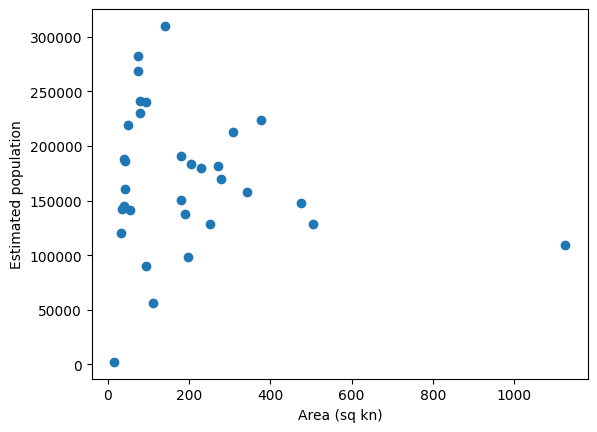

In [41]:
complete_analysis('Unitary Authority')

(32, 3)


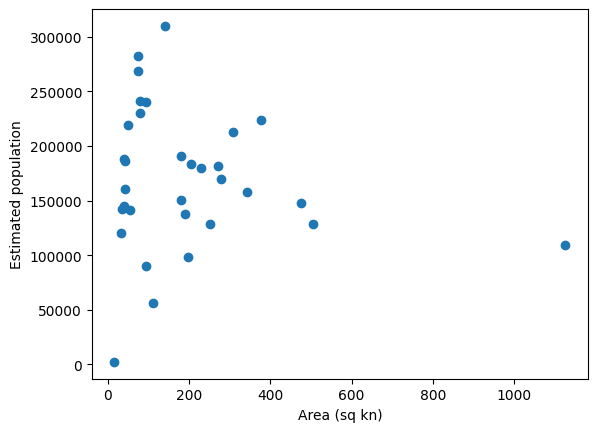

In [42]:
geo = extract('Unitary Authority')
geo = geo.sort_values(by='Area (sq km)', ascending=True)
print(geo.shape)
visualise(geo)


A cluster analysis - KMeans - suggest 5 centroids may be suitable. The population appears to impact on the centroid over the area.   

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

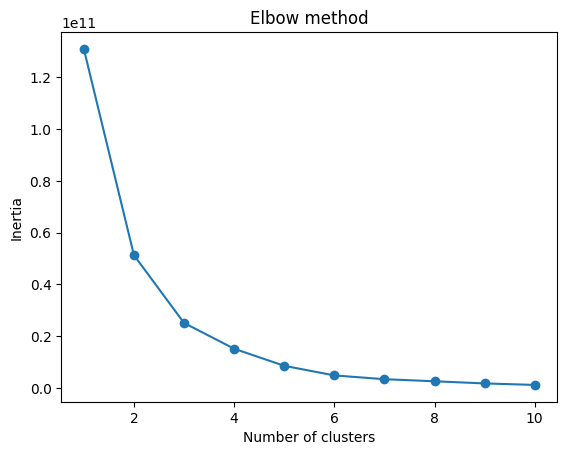

In [43]:
x = geo['Area (sq km)'].values
y = geo['est_pop'].values
data_to_fit = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_to_fit)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


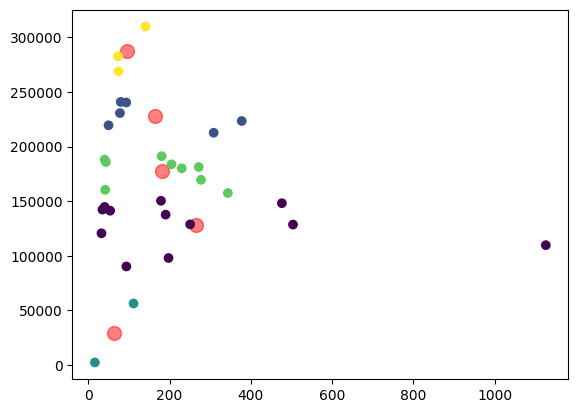

------ Centers --------


array([[2.64922342e+02, 1.28320667e+05],
       [1.64575217e+02, 2.27968500e+05],
       [6.38820000e+01, 2.91735000e+04],
       [1.81528900e+02, 1.77521778e+05],
       [9.62899000e+01, 2.87261333e+05]])

In [44]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data_to_fit)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5);
plt.scatter(x, y, c=kmeans.labels_)
plt.show()
print("------ Centers --------")
centers

### All data

(315669, 4)


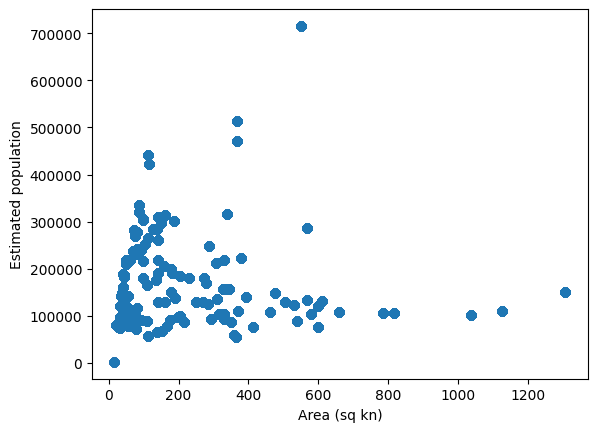

In [45]:
geo = data_num
geo = geo.sort_values(by='Area (sq km)', ascending=True)
geo = geo.drop_duplicates().dropna()
geo = geo.loc[geo.est_pop < 9e5]
print(geo.shape)
visualise(geo)


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

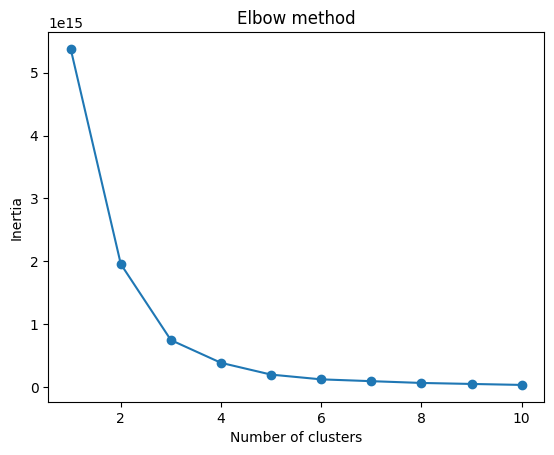

In [46]:
x = geo['Area (sq km)'].values
y = geo['est_pop'].values
data_to_fit = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_to_fit)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

A cluster analysis - KMeans - suggest 5 centroids may be suitable. The population appears to impact on the centroid over the area.   

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


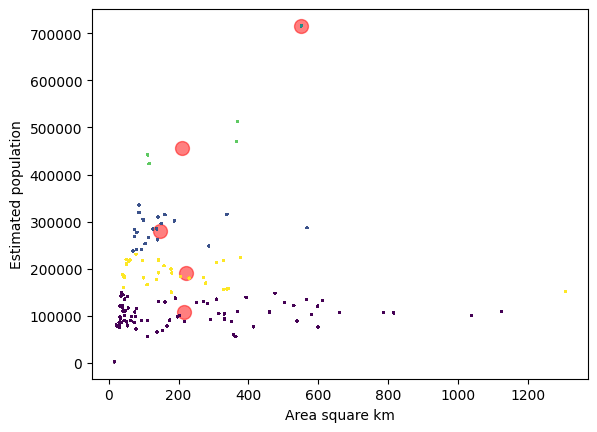

------ Centers --------


array([[2.16001231e+02, 1.07181088e+05],
       [1.46898757e+02, 2.79987631e+05],
       [5.51706700e+02, 7.15609000e+05],
       [2.10517597e+02, 4.55918908e+05],
       [2.20252450e+02, 1.91956420e+05]])

In [47]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data_to_fit)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5);
plt.scatter(x, y, c=kmeans.labels_, s= 0.5)
plt.xlabel('Area square km')
plt.ylabel('Estimated population')
plt.show()
print("------ Centers --------")
centers

### Density of population

The metric _people per sq_km_ is skewed to the right. The difference between the arithmetical mean and median is rather large. The dispersion is also quite large. A 3D representation at a logarithm scale suggest the size of an area may limit its population density. 

We surmise the density of population may be restricted to its size, but is can vary immensely for a certain area. Certain factors such as use of the land and the geography itself may impact on the relationship between the population and its area. None of those factors were clearly captured in the data. 

In [48]:
cols = ['Area (sq km)', 'est_pop', 'pp_sq_m']
geo = data.loc[:, cols]
geo = geo.dropna()
geo = geo.drop_duplicates()
geo.describe()

,Area (sq km),est_pop,pp_sq_m
count,135.000000,1.350000e+02,135.000000
mean,229.504121,2.264777e+05,1690.937385
std,255.569467,6.274943e+05,1349.913246
min,16.317700,2.140000e+03,97.047386
25%,58.270600,9.844850e+04,473.015434
50%,139.792300,1.353810e+05,1343.116544
75%,328.650750,2.183305e+05,2835.794533
max,1572.030800,7.322403e+06,4657.925913


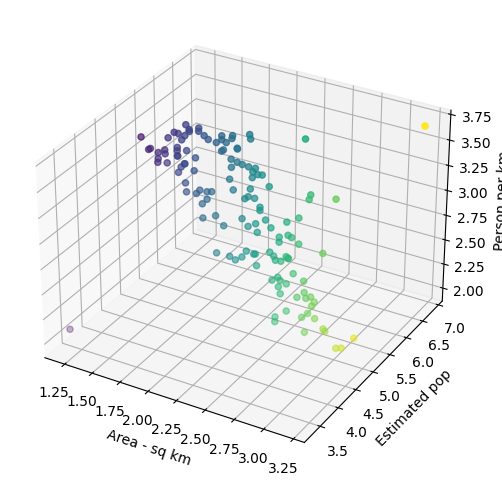

<Figure size 2000x1600 with 0 Axes>

In [49]:
fig = plt.figure(figsize=(6,6))

#ax = Axes3D(fig) # Method 1
ax = fig.add_subplot(111, projection='3d')

x = np.log10(geo['Area (sq km)'])
y = np.log10(geo.est_pop)
z = np.log10(geo.pp_sq_m)

plt.figure(figsize = [20,16])
ax.scatter(x, y, z, c=x, marker='o')
ax.set_xlabel('Area - sq km')
ax.set_ylabel('Estimated pop')
ax.set_zlabel('Person per km')

plt.show()

       Area (sq km)         Price       pp_sq_m       est_pop
count  7.853837e+06  7.853837e+06  7.853837e+06  5.208853e+06
mean   4.194698e+02  2.209744e+05  2.599774e+03  1.372225e+06
std    5.338312e+02  5.708082e+05  1.613246e+03  2.584126e+06
min    1.631770e+01  1.000000e+00  9.704739e+01  2.140000e+03
25%    7.461320e+01  1.025000e+05  9.843264e+02  1.340490e+05
50%    1.581281e+02  1.550000e+05  2.608139e+03  2.380160e+05
75%    4.144144e+02  2.407510e+05  4.011644e+03  4.418580e+05
max    1.572031e+03  9.890000e+07  5.218986e+03  7.322403e+06
                            OLS Regression Results                            
Dep. Variable:                pp_sq_m   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                 1.586e+06
Date:                Sun, 16 Feb 2025   Prob (F-statistic):               0.00
Time:                        13:30:50   Log-Lik

Text(0, 0.5, 'Population density (pp/km^2)')

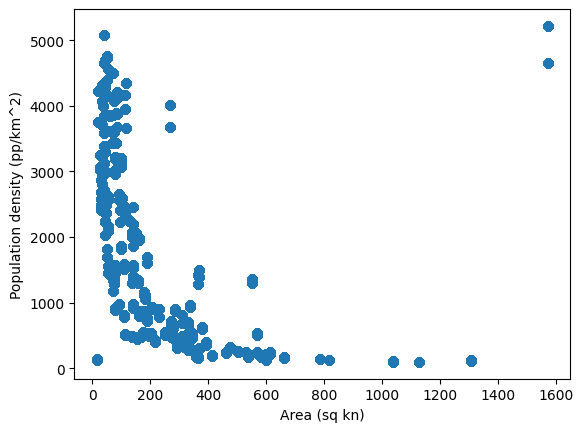

In [50]:
geo = data_num
print(geo.describe())
geo = geo.sort_values(by='Area (sq km)', ascending=True)

x = geo[['Area (sq km)']] 
y = geo[['pp_sq_m']]
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())
print("---- params / coeficient -------")
print(model.params)
print('------------p values----------')
print(model.pvalues)


plt.scatter(geo[['Area (sq km)']] , geo[['pp_sq_m']])
plt.xlabel("Area (sq kn)")
plt.ylabel("Population density (pp/km^2)")

(7853837, 4)


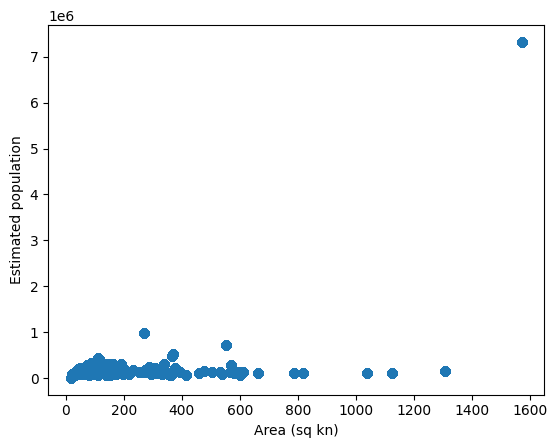

In [51]:
geo = data_num
geo = geo.sort_values(by='Area (sq km)', ascending=True)
print(geo.shape)
visualise(geo)


A cluster analysis - KMeans - suggest 5 centroids may be suitable. The population appears to impact on the centroid over the area.   

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

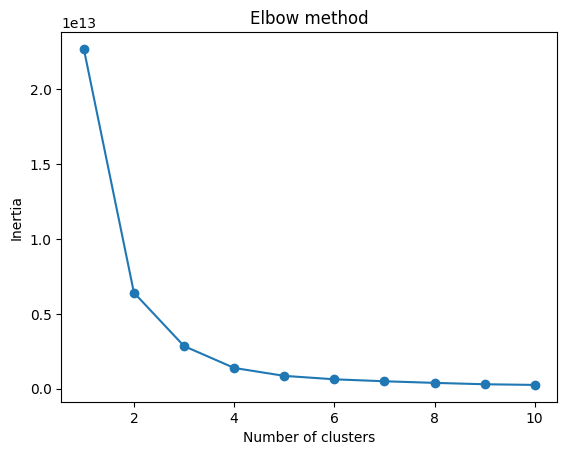

In [52]:
x = geo['Area (sq km)'].values
y = geo['pp_sq_m'].values
data_to_fit = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_to_fit)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


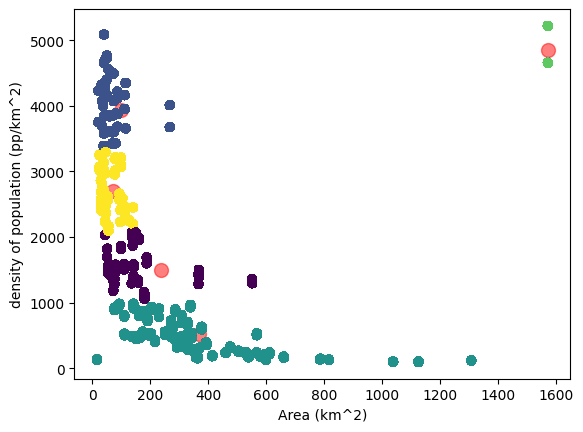

------ Centers --------


array([[ 236.8852271 , 1496.3982078 ],
       [  98.17824303, 3939.25590807],
       [ 367.61878674,  529.88931171],
       [1572.03080001, 4852.80537318],
       [  71.12833405, 2706.46815779]])

In [53]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data_to_fit)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5);
plt.scatter(x, y, c=kmeans.labels_)
plt.xlabel("Area (km^2)")
plt.ylabel("density of population (pp/km^2)")
plt.show()
print("------ Centers --------")
centers

In [54]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2
geo = geo.loc[:,['Area (sq km)','est_pop']]
geo = geo.drop_duplicates()
geo = geo.dropna()

nl = "\n"
stat, p, dof, expected = chi2_contingency(geo)
print(stat)

print(f"Chi2 value= {chi2}{nl}p-value= {p}{nl}Degrees of freedom= {dof}{nl}")

76211.43788470532
Chi2 value= <scipy.stats._continuous_distns.chi2_gen object at 0x791ac03beec0>
p-value= 0.0
Degrees of freedom= 134



In [55]:
data['label'] = kmeans.labels_
data.to_csv('data_with_labels.csv')

# Is there a relationship between houses prices and clusters of density and areas?

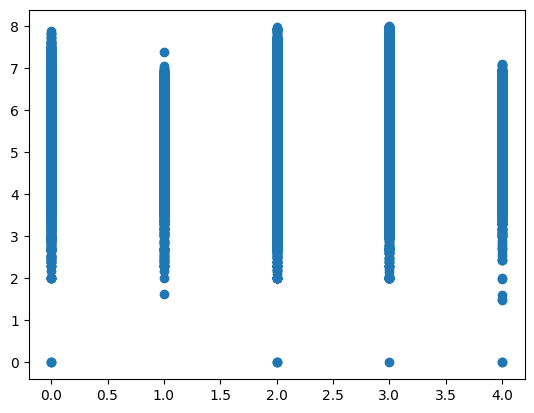

In [56]:
x = data['label']
y = np.log10(data['Price'])
plt.scatter(x,y)

In [57]:
grouping = data.groupby(['label'])['Price'].describe().reset_index()
grouping

,label,count,mean,std,min,25%,50%,75%,max
0,0,1245304.0,218210.124202,3.585663e+05,1.0,112000.0,163351.0,245000.0,76155307.0
1,1,1841524.0,160907.540751,1.540350e+05,42.0,83500.0,129000.0,191000.0,24750000.0
2,2,1979237.0,197210.458332,4.471786e+05,1.0,108000.0,153000.0,225000.0,98765391.0
3,3,1261082.0,421931.738787,1.213304e+06,1.0,175500.0,265000.0,425000.0,98900000.0
4,4,1526690.0,160495.838893,1.590822e+05,1.0,85000.0,129000.0,189950.0,12400000.0


In [58]:
grouping = data.groupby(['label'])['Name'].apply(set).reset_index()
g_4 = grouping.loc[4,'Name']
g_4


{'BARNSLEY',
 'BEDFORD',
 'BIRMINGHAM',
 'BLACKPOOL',
 'BOLTON',
 'BRADFORD',
 'BURNLEY',
 'BURY',
 'CAMBRIDGE',
 'CARLISLE',
 'CHORLEY',
 'DONCASTER',
 'DUDLEY',
 'GATESHEAD',
 'HARROGATE',
 'HARTLEPOOL',
 'IPSWICH',
 'LANCASTER',
 'LEEDS',
 'LIVERPOOL',
 'LONDON',
 'LUTON',
 'MANCHESTER',
 'MIDDLESBROUGH',
 'NEWCASTLE UPON TYNE',
 'NORWICH',
 'OLDHAM',
 'PETERBOROUGH',
 'PRESTON',
 'REDDITCH',
 'RUGBY',
 'SCARBOROUGH',
 'SELBY',
 'SOLIHULL',
 'SOUTHEND-ON-SEA',
 'ST. HELENS',
 'STAFFORD',
 'STOCKTON-ON-TEES',
 'TAMWORTH',
 'WALSALL',
 'WARRINGTON',
 'WARWICK',
 'WIGAN',
 'WIRRAL',
 'WOLVERHAMPTON',
 'WORCESTER',
 'YORK'}

## Findings and conclusion

We applied a chi-square test. We use the  H0 (Null Hypothesis): There is no relationship between the area  and estimated population. We also used the the H1 (Alternative Hypothesis): There is a relationship between an area and an estimated population. $p-value = 0$ and $p < 0.01$ suggest we can reject the Null hupothesis. Therefore, we surmise there is a relationship between an area and an estimated population. 

We have shown a strong Pearson correlation between the area (square km) and estimated population may exist - i.e., 0.94. A weaker Pearson correlation between the area and the people per square km  was approximated to 0.40.  Some KMeans analysis suggests the 5 centroids across each type of geography and across the whole dataset. Each cluster appears to be mostly guided by the estimated population or population density. Therefore, we surmise and confirm that an estimated population may vary across an area. The latter may impact on the population density. Other factors may impact on the population density. Further research based on employment, geography features, and other aspects should be further conducted.

